# Woche 8: Data Visualization - Übung am eigenen Projekt

**Ziel dieser Übung:** Nachdem Sie die wichtigsten Visualisierungstechniken kennengelernt haben, wenden Sie dieses Wissen Schritt für Schritt auf Ihren eigenen bereinigten Datensatz an.

**Arbeitsweise:**
- Arbeiten Sie die Aufgaben nacheinander durch
- Nutzen Sie die Code-Zellen für Ihre Implementierung
- Orientieren Sie sich an den Beispielen aus dem Airbnb-Notebook
- Erstellen Sie aussagekräftige Visualisierungen für Ihre Forschungsfrage
- Speichern Sie wichtige Visualisierungen als Bilddateien

---
## 1. Bibliotheken importieren und Daten einlesen

**Aufgabe:** Importieren Sie die notwendigen Bibliotheken und laden Sie Ihren bereinigten Datensatz aus Woche 7.

**Hinweise:**
- Importieren Sie: `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`, `plotly.express`, `plotly.graph_objects`
- Konfigurieren Sie die Visualisierungsstile
- Laden Sie Ihren bereinigten CSV-Datensatz

In [1]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Visualisierungsstile konfigurieren
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Bereinigten Datensatz einlesen
df = pd.read_csv('metadata_cleaned.csv')


---
## 2. Ersten Überblick verschaffen

**Aufgabe:** Verschaffen Sie sich einen Überblick über Ihren bereinigten Datensatz.

**Was Sie prüfen sollten:**
- Dimensionen des Datensatzes
- Datentypen der Spalten
- Statistische Kennzahlen
- Erste Zeilen anzeigen

In [2]:
# Dimensionen
print('\n Dimensionen \n')
print(df.shape)

# Erste Zeilen
print('\n Erste Zeilen \n')
print(df.head())

# Informationen zu Spalten

print('\n Informationen zu den Spalten \n')
print(df.info())

# Statistische Übersicht

# ?? Was ist hier gemeint



 Dimensionen 

(9696, 15)

 Erste Zeilen 

    image_filename  split           drone_types  num_drones condition  \
0  drone_00000.jpg  train   mohajer_6;mohajer_6           2      hazy   
1  drone_00001.jpg  train             mohajer_6           1     night   
2  drone_00003.jpg  train            shahed_238           1       day   
3  drone_00004.jpg  train            mq9_reaper           1     night   
4  drone_00005.jpg  train  mohajer_6;shahed_238           2       day   

   avg_drone_size_pct  has_occlusion  has_motion_blur background_source  \
0              0.0017          False            False     hazy_0030.jpg   
1              0.0025          False             True    night_0017.jpg   
2              0.0045          False             True      day_0005.jpg   
3              0.0020          False             True    night_0060.jpg   
4              0.0006           True            False      day_0023.jpg   

   is_combat_drone  mq9_reaper  shahed_136  shahed_238  mohajer_6 

---
## 3. Univariate Analysen - Verteilungen einzelner Variablen

**Aufgabe:** Visualisieren Sie die Verteilung einzelner Variablen.

**Für numerische Variablen:**
- Histogramme
- Boxplots
- Violin Plots
- Density Plots

**Für kategoriale Variablen:**
- Bar Charts
- Count Plots
- Pie Charts (bei wenigen Kategorien)

In [3]:
# Numerische Spalten identifizieren
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerische Spalten: {list(numeric_cols)}")


Numerische Spalten: ['num_drones', 'avg_drone_size_pct', 'mq9_reaper', 'shahed_136', 'shahed_238', 'mohajer_6', 'dji_mavic']


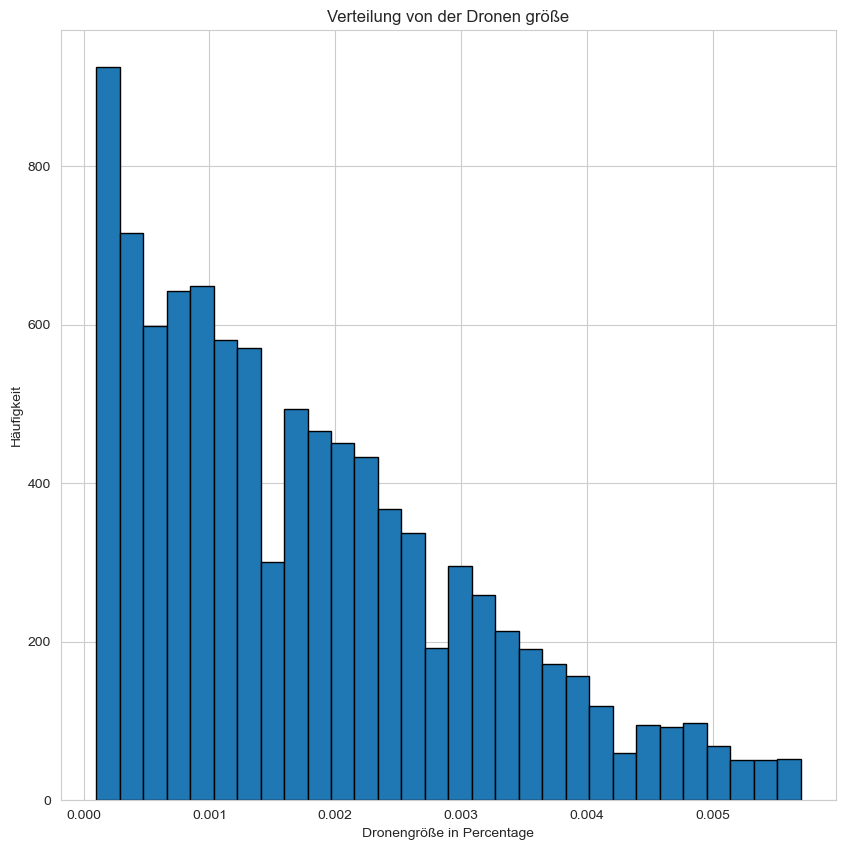

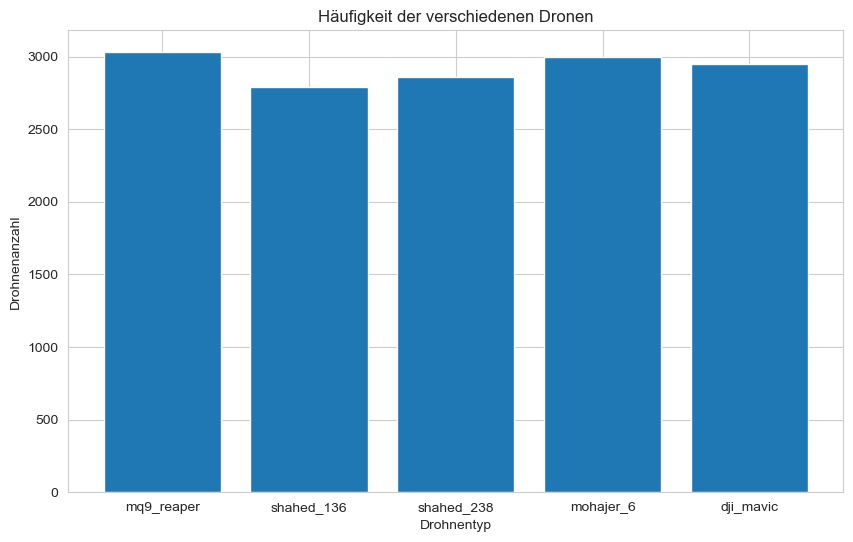

In [4]:
# Beispiel: Histogramm für eine numerische Variable
plt.figure(figsize=(10, 10))
plt.hist(df['avg_drone_size_pct'], bins=30, edgecolor='black')
plt.title('Verteilung von der Dronen größe')
plt.xlabel('Dronengröße in Percentage')
plt.ylabel('Häufigkeit')
plt.show()
#Was für ein Bins wert macht hier sinn?

dronen_spalten = ['mq9_reaper', 'shahed_136', 'shahed_238', 'mohajer_6', 'dji_mavic'] 

dronen_art = df[dronen_spalten].sum()

plt.bar(dronen_art.index, dronen_art.values)

plt.title('Häufigkeit der verschiedenen Dronen')
plt.xlabel('Drohnentyp')
plt.ylabel('Drohnenanzahl')
plt.show()

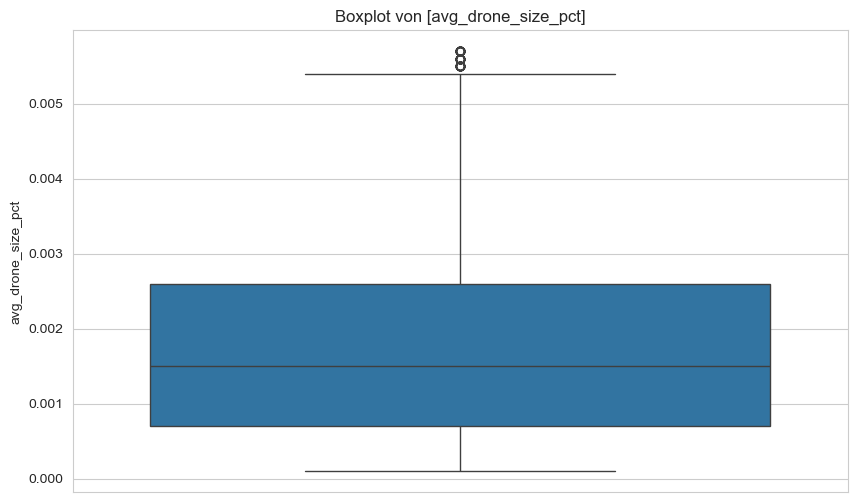

In [5]:
# Beispiel: Boxplot für eine numerische Variable
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['avg_drone_size_pct'])
plt.title('Boxplot von [avg_drone_size_pct]')
plt.show()



In [6]:
# Kategoriale Spalten identifizieren
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"Kategoriale Spalten: {list(categorical_cols)}")


Kategoriale Spalten: ['image_filename', 'split', 'drone_types', 'condition', 'background_source']


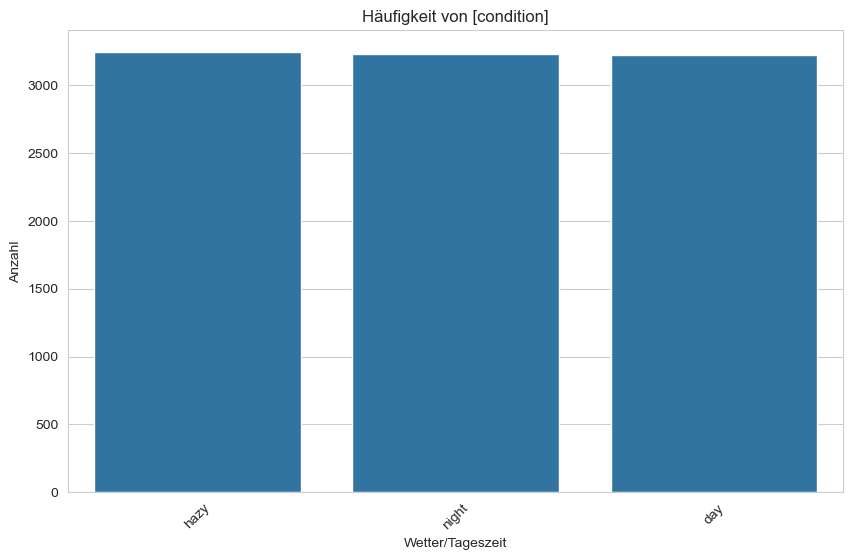

In [7]:
# Beispiel: Count Plot für eine kategoriale Variable
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='condition')
plt.title('Häufigkeit von [condition]')
plt.xlabel('Wetter/Tageszeit')
plt.ylabel('Anzahl')
plt.xticks(rotation=45)
plt.show()


---
## 4. Bivariate Analysen - Beziehungen zwischen zwei Variablen

**Aufgabe:** Untersuchen Sie Beziehungen zwischen zwei Variablen.

**Mögliche Visualisierungen:**
- Scatter Plots (numerisch vs. numerisch)
- Line Plots (bei Zeitreihen)
- Grouped Bar Charts (kategorial vs. numerisch)
- Box Plots nach Kategorien (kategorial vs. numerisch)
- Violin Plots nach Kategorien

In [8]:


# Beispiel: Scatter Plot (numerisch vs. numerisch)
#plt.figure(figsize=(10, 6))
#plt.scatter(df['avg_drone_size_pct'], df['mq9_reaper'], alpha=0.5)
#plt.title('Beziehung zwischen [Spalte1] und [Spalte2]')
#plt.xlabel('[Spalte1]')
#plt.ylabel('[Spalte2]')
#plt.show()


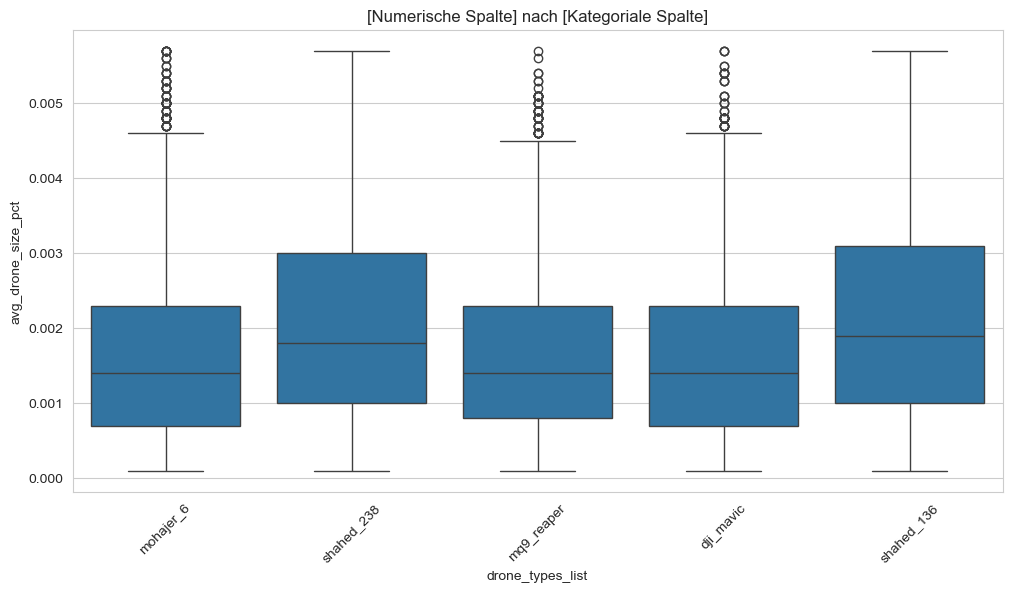

In [22]:
# Beispiel: Boxplot nach Kategorien


#Exloden, da mit der Dronenart von oben es schwierig wird zu arbeiten (vervielfachen
#jede Zeile und pro Zeile zeigen wir Dronenart an 

df['drone_types_list'] = df['drone_types'].str.split(';')

df_exploded = df.explode('drone_types_list')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_exploded, x='drone_types_list', y='avg_drone_size_pct')
plt.title('[Numerische Spalte] nach [Kategoriale Spalte]')
plt.xticks(rotation=45)
plt.show()


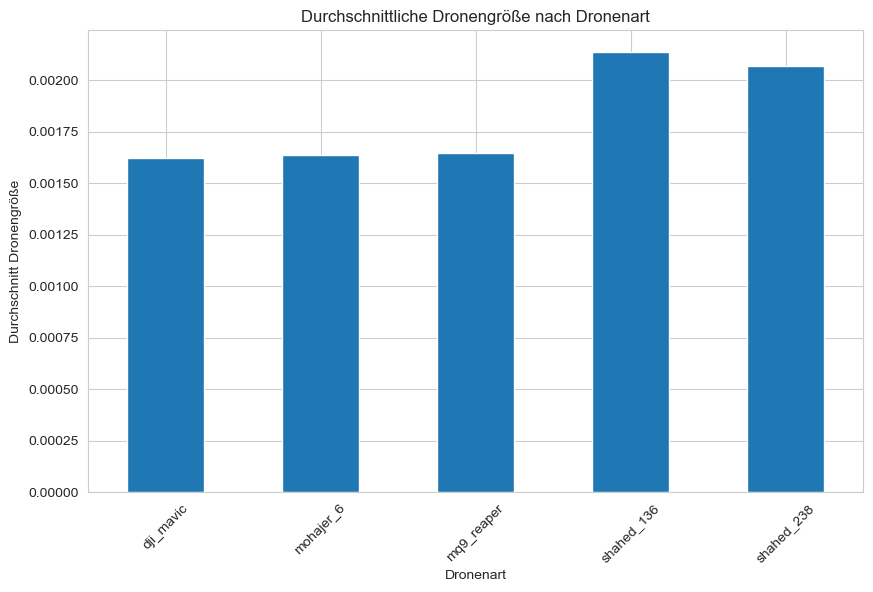

In [21]:
# Beispiel: Grouped Bar Chart


grouped_data = df_exploded.groupby('drone_types_list')['avg_drone_size_pct'].mean()

plt.figure(figsize=(10, 6))

grouped_data.plot(kind='bar')

plt.title('Durchschnittliche Dronengröße nach Dronenart')
plt.xlabel('Dronenart')
plt.ylabel('Durchschnitt Dronengröße')
plt.xticks(rotation=45)

plt.show()


---
## 5. Korrelationsanalyse

**Aufgabe:** Untersuchen Sie Korrelationen zwischen numerischen Variablen.

**Visualisierungen:**
- Korrelationsmatrix als Heatmap
- Pairplot für ausgewählte Variablen

**Hinweis:** Korrelationen zeigen nur lineare Beziehungen!

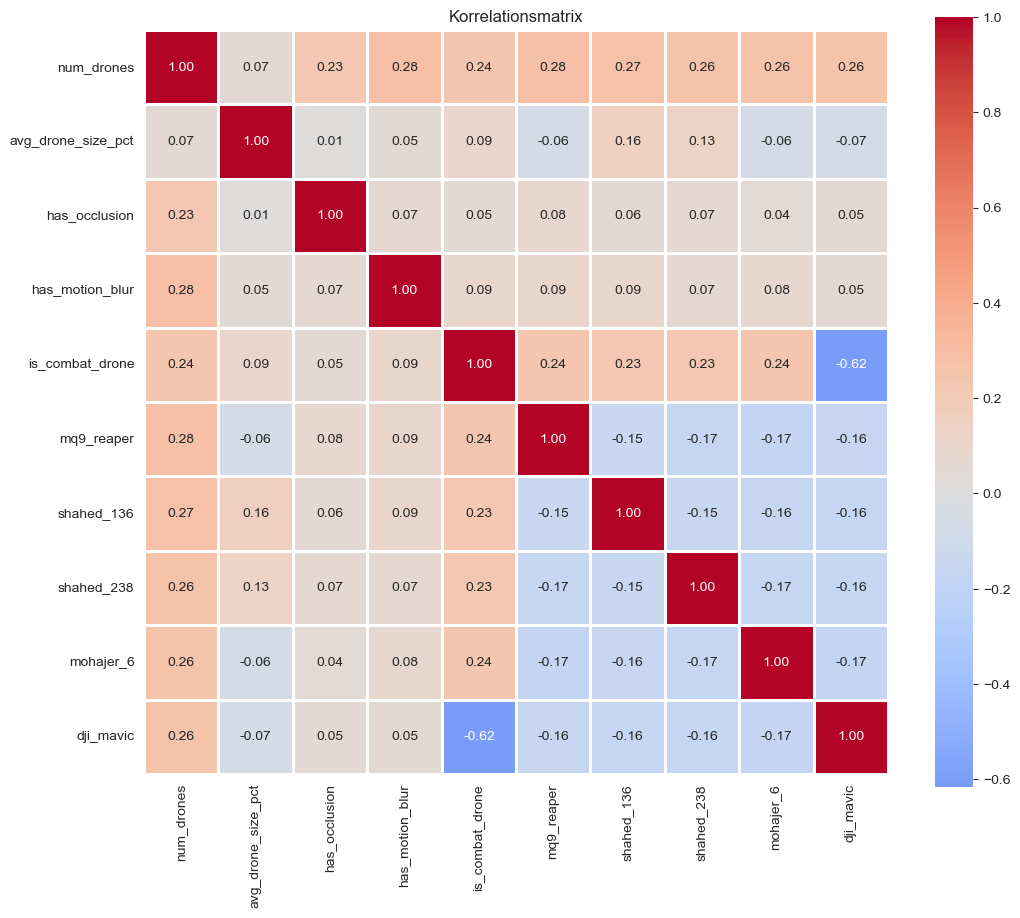

In [35]:
#Korrelationsmatrix berechnen
#correlation_matrix = df['avg_drone_size_pct'].corr(df['num_drones'])
correlation_matrix = df.corr(numeric_only=True)


#Heatmap der Korrelationen
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Korrelationsmatrix')
plt.show()


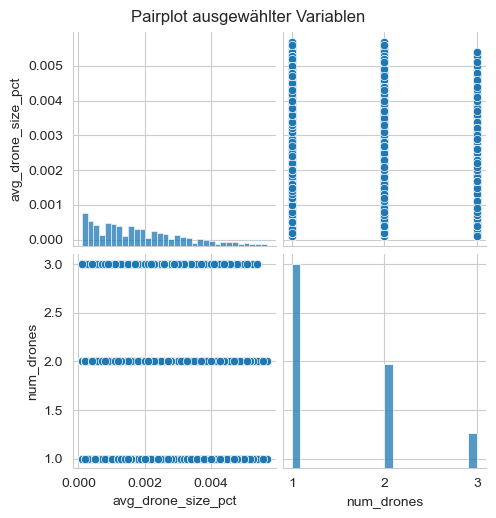

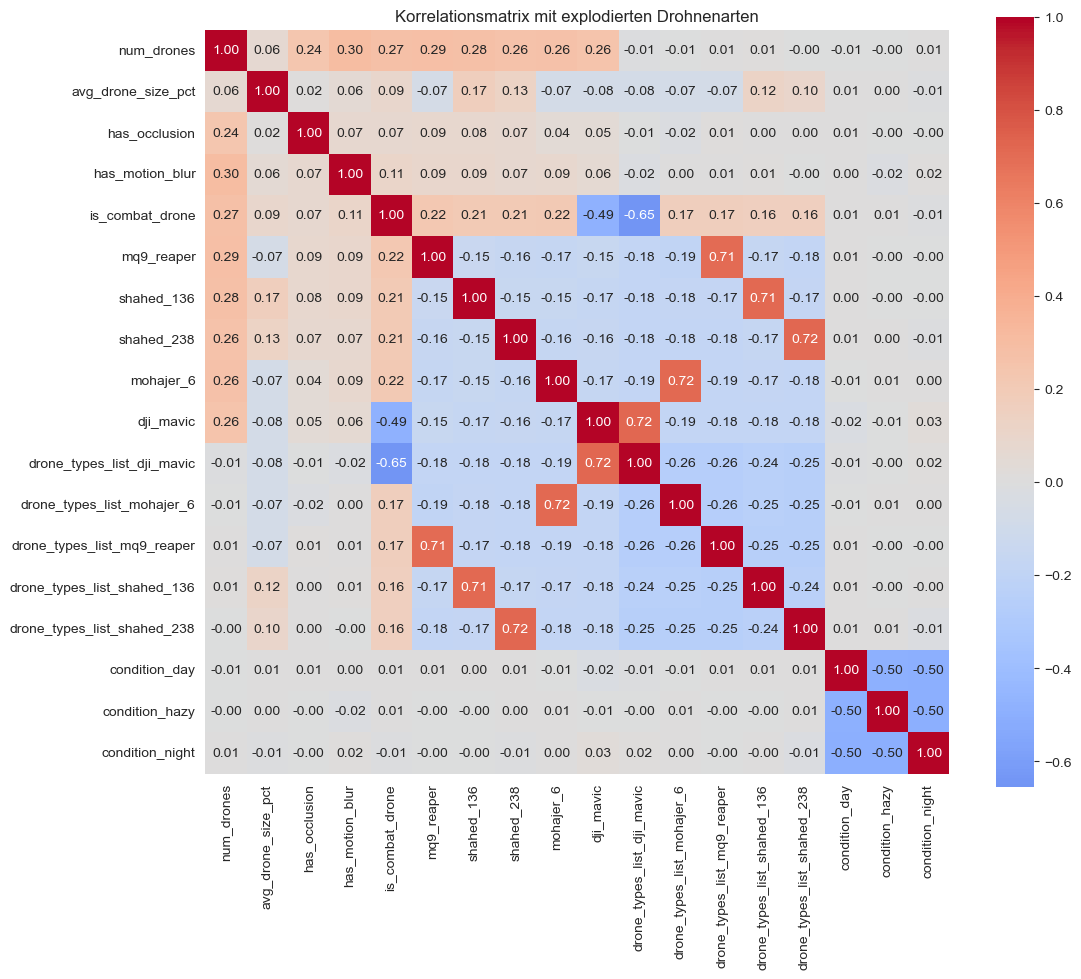

In [41]:
# Optional: Pairplot für ausgewählte Variablen
selected_cols = ['avg_drone_size_pct','num_drones']
sns.pairplot(df[selected_cols])
plt.suptitle('Pairplot ausgewählter Variablen', y=1.02)
plt.show()


# Exploded Df für Kategorie und Dronengröße Heatmap

#get dummies bildet one hot encoding werte also true false für alle Kateogrischen Spalten

df_heatmap = pd.get_dummies(df_exploded, columns=['drone_types_list', 'condition'], dtype=int)

df_heatmap_selected = df_heatmap

correlation_matrix_all = df_heatmap.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')

plt.title('Korrelationsmatrix mit explodierten Drohnenarten')
plt.show()

---
## 6. Multivariate Analysen

**Aufgabe:** Visualisieren Sie Beziehungen zwischen mehreren Variablen gleichzeitig.

**Mögliche Visualisierungen:**
- Scatter Plots mit Farb- oder Größenkodierung
- Facet Grids (mehrere Subplots)
- Stacked Bar Charts
- Bubble Charts

In [ ]:
# Beispiel: Scatter Plot mit Farbkodierung
# plt.figure(figsize=(12, 6))
# for category in df['kategoriale_spalte'].unique():
#     subset = df[df['kategoriale_spalte'] == category]
#     plt.scatter(subset['spalte1'], subset['spalte2'], label=category, alpha=0.6)
# plt.title('Beziehung mit Kategorisierung')
# plt.xlabel('[Spalte1]')
# plt.ylabel('[Spalte2]')
# plt.legend()
# plt.show()


In [ ]:
# Beispiel: Seaborn FacetGrid
# g = sns.FacetGrid(df, col='kategoriale_spalte', height=4, aspect=1.5)
# g.map(plt.hist, 'numerische_spalte', bins=20)
# g.set_axis_labels('[Numerische Spalte]', 'Häufigkeit')
# g.set_titles(col_template='{col_name}')
# plt.show()


---
## 7. Interaktive Visualisierungen mit Plotly (falls sinnvoll an Ihrem Datensatz)

**Aufgabe:** Erstellen Sie interaktive Visualisierungen mit Plotly.

**Vorteile von interaktiven Plots:**
- Zoom- und Pan-Funktionen
- Hover-Informationen
- Dynamische Filter
- Bessere Exploration komplexer Daten

**Hinweis:** Diese Plots sind besonders nützlich für Ihre Streamlit-App!

In [ ]:
# Beispiel: Interaktiver Scatter Plot
# fig = px.scatter(df, 
#                  x='spalte1', 
#                  y='spalte2',
#                  color='kategoriale_spalte',
#                  size='spalte3',  # optional: Größe nach dritter Variable
#                  hover_data=['spalte4', 'spalte5'],  # zusätzliche Infos beim Hovern
#                  title='Interaktiver Scatter Plot')
# fig.show()


In [ ]:
# Beispiel: Interaktives Histogramm
# fig = px.histogram(df, 
#                    x='numerische_spalte',
#                    color='kategoriale_spalte',
#                    marginal='box',  # Boxplot am Rand
#                    title='Interaktives Histogramm')
# fig.show()


In [ ]:
# Beispiel: Interaktiver Box Plot
# fig = px.box(df, 
#              x='kategoriale_spalte', 
#              y='numerische_spalte',
#              color='kategoriale_spalte',
#              title='Interaktiver Box Plot')
# fig.show()


In [ ]:
# Optional: Interaktive Korrelationsmatrix
# fig = px.imshow(correlation_matrix,
#                 text_auto=True,
#                 color_continuous_scale='RdBu_r',
#                 title='Interaktive Korrelationsmatrix')
# fig.show()


---
## 8. Visualisierungen für Ihre Forschungsfrage

**Aufgabe:** Nachdem Sie in den Aufgaben 1-7 "experimentiert" haben, erstellen Sie jetzt spezifische Visualisierungen, die Ihre Forschungsfrage beantworten.

**Überlegen Sie:**
- Welche Variablen sind für Ihre Forschungsfrage am wichtigsten?
- Welche Visualisierungen zeigen die relevanten Muster am besten?
- Welche Insights können Sie aus den Daten gewinnen?

**Erstellen Sie mindestens 3 aussagekräftige Visualisierungen!**

In [ ]:
# Visualisierung 1: [Beschreibung]



**Interpretation Visualisierung 1:**
- ...

In [ ]:
# Visualisierung 2: [Beschreibung]



**Interpretation Visualisierung 2:**
- ...

In [ ]:
# Visualisierung 3: [Beschreibung]



**Interpretation Visualisierung 3:**
- ...

In [ ]:
# Weitere Visualisierungen nach Bedarf



---
## 9. Visualisierungen speichern

**Aufgabe:** Speichern Sie Ihre wichtigsten Visualisierungen als Bilddateien.

**Hinweise:**
- Speichern Sie Plots in hoher Qualität (dpi=300)
- Verwenden Sie aussagekräftige Dateinamen
- Diese Bilder können Sie in Präsentationen oder Berichten verwenden
- Für Streamlit: Visualisierungen werden direkt im Code erstellt, nicht als Bilder eingebunden

In [ ]:
# Beispiel: Matplotlib/Seaborn Plot speichern
# plt.figure(figsize=(10, 6))
# # ... Ihr Plot-Code ...
# plt.savefig('plot_name.png', dpi=300, bbox_inches='tight')
# plt.show()


In [ ]:
# Beispiel: Plotly Plot als HTML speichern (für interaktive Nutzung)
# fig = px.scatter(...)  # Ihr Plotly Plot
# fig.write_html('interactive_plot.html')


---
## 10. Qualitätskontrolle durch Visualisierung

**Aufgabe:** Nutzen Sie Visualisierungen zur Qualitätskontrolle Ihrer Daten.

**Prüfen Sie:**
- Sind alle Ausreißer sinnvoll?
- Gibt es unerwartete Muster?
- Sind kategoriale Variablen konsistent kodiert?
- Gibt es offensichtliche Datenfehler?

**Falls Sie Probleme entdecken:** Gehen Sie zurück zu Ihrem Data Cleaning Notebook und korrigieren Sie diese!

In [ ]:
# Qualitätskontrolle: Überprüfen Sie Ihre Daten visuell



**Beobachtungen aus der Qualitätskontrolle:**
- ...

---
## Reflexion

**Dokumentieren Sie Ihre Arbeit:**

Beantworten Sie folgende Fragen:

1. Welche Visualisierungen waren am aufschlussreichsten für Ihre Forschungsfrage?
2. Welche unerwarteten Muster oder Erkenntnisse haben Sie entdeckt?
3. Welche Visualisierungstypen eignen sich am besten für Ihren Datensatz?
4. Welche Visualisierungen planen Sie für Ihre Streamlit-App zu verwenden?
5. Gab es Herausforderungen bei der Visualisierung? Wie haben Sie diese gelöst?
6. Haben die Visualisierungen neue Fragen aufgeworfen oder Ideen für weitere Analysen gegeben?

### Ihre Reflexion:

1. **Aufschlussreichste Visualisierungen:**
   - ...

2. **Unerwartete Erkenntnisse:**
   - ...

3. **Geeignetste Visualisierungstypen:**
   - ...

4. **Geplante Visualisierungen für Streamlit:**
   - ...

5. **Herausforderungen und Lösungen:**
   - ...

6. **Neue Fragen und Ideen:**
   - ...

---
## Zusammenfassung und nächste Schritte

**Sie haben in dieser Übung:**
- ✅ Verschiedene Visualisierungstypen auf Ihre Daten angewendet
- ✅ Univariate, bivariate und multivariate Analysen durchgeführt
- ✅ Interaktive Visualisierungen mit Plotly erstellt
- ✅ Spezifische Visualisierungen für Ihre Forschungsfrage entwickelt
- ✅ Ihre Datenqualität visuell überprüft

**Nächste Woche (Woche 9):**
- Machine Learning Grundlagen
- Erste ML-Modelle auf Ihren Daten trainieren
- Modell-Evaluation

**Tipp:** Speichern Sie dieses Notebook gut ab - die Visualisierungen bilden die Grundlage für Ihre Streamlit-App in Woche 10 und 11!